In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Celda 1 — Verificación de entorno
import sys
 
print(f"Python: {sys.version}")
 
for paquete in ["torch", "sklearn", "matplotlib", "numpy"]:
 try:
    modulo = __import__(paquete)
    print(f"{paquete}: {modulo.__version__} ✓")
 except ImportError:
    print(f"{paquete} no instalado — ejecuta: pip install {paquete}")

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
torch: 2.13.0+cpu ✓
sklearn: 1.9.0 ✓
matplotlib: 3.11.1 ✓
numpy: 2.5.1 ✓


Dimensiones: (2573, 1448)
Píxeles totales: 3725704
Valor mínimo: 1
Valor máximo: 217


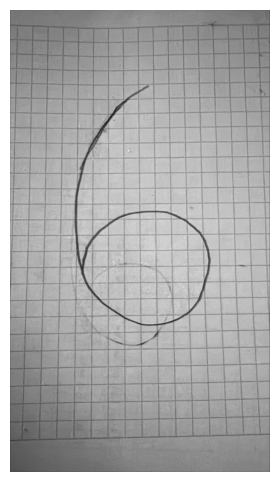

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

ruta = r"D:\CosasCodigo\IA\TrabajosFIA\Imagenes\Image.jpg"

imagen = Image.open(ruta).convert("L")
imagen_array = np.array(imagen)

X = imagen_array.flatten()

print(f"Dimensiones: {imagen_array.shape}")
print(f"Píxeles totales: {X.shape[0]}")
print(f"Valor mínimo: {X.min()}")
print(f"Valor máximo: {X.max()}")

plt.figure(figsize=(6, 6))
plt.imshow(imagen_array, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
# Celda 3 — Partición train / validation / test
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

datos = load_digits()

X_dataset = datos.data
y_dataset = datos.target

X_train, X_temp, y_train, y_temp = train_test_split(
    X_dataset, y_dataset, test_size=0.3, stratify=y_dataset, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

escalador = StandardScaler()

X_train_esc = escalador.fit_transform(X_train)
X_val_esc = escalador.transform(X_val)
X_test_esc = escalador.transform(X_test)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 1257 | Validation: 270 | Test: 270


In [5]:
# Celda 4 — Modelo baseline (sin redes neuronales)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_esc, y_train)

pred_test_baseline = baseline.predict(X_test_esc)
acc_baseline = accuracy_score(y_test, pred_test_baseline)

print(f"Accuracy (regresión logística) en test: {acc_baseline:.3f}")

Accuracy (regresión logística) en test: 0.985


In [28]:
# Celda 5 — Arquitectura del MLP
import torch
import torch.nn as nn

torch.manual_seed(42)

class MLPDigits(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.red(x)

modelo = MLPDigits()

print(modelo)

MLPDigits(
  (red): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [29]:
# Celda 6 — Entrenamiento
import torch.optim as optim

X_train_t = torch.tensor(X_train_esc, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_esc, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

mejor_val_loss = float("inf")
paciencia, epocas_sin_mejora = 15, 0
historial = {"train_loss": [], "val_loss": []}

for epoch in range(200):
    modelo.train()
    optimizador.zero_grad()

    salida = modelo(X_train_t)
    perdida_train = criterio(salida, y_train_t)

    perdida_train.backward()
    optimizador.step()

    modelo.eval()

    with torch.no_grad():
        salida_val = modelo(X_val_t)
        perdida_val = criterio(salida_val, y_val_t)

    historial["train_loss"].append(perdida_train.item())
    historial["val_loss"].append(perdida_val.item())

    if perdida_val.item() < mejor_val_loss:
        mejor_val_loss = perdida_val.item()
        epocas_sin_mejora = 0
        mejores_pesos = {
            k: v.clone() for k, v in modelo.state_dict().items()
        }
    else:
        epocas_sin_mejora += 1

    if epocas_sin_mejora >= paciencia:
        print(
            f"Early stopping en epoch {epoch} "
            f"(sin mejora en {paciencia} epochs)"
        )
        break

modelo.load_state_dict(mejores_pesos)

<All keys matched successfully>

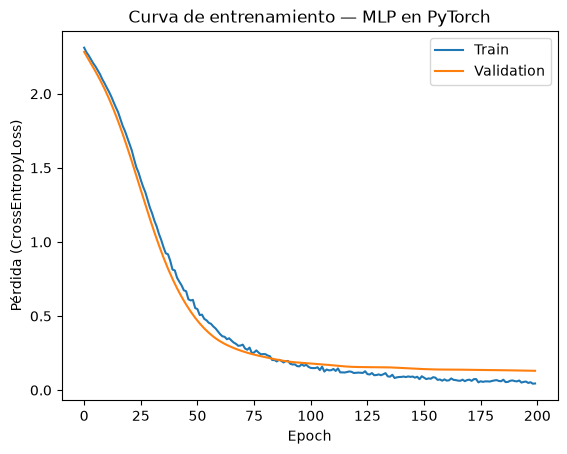

In [30]:
# Celda 7 — Curva de pérdida
plt.plot(historial["train_loss"], label="Train")
plt.plot(historial["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.title("Curva de entrenamiento — MLP en PyTorch")
plt.legend()
plt.show()

Predicción de la imagen: 4


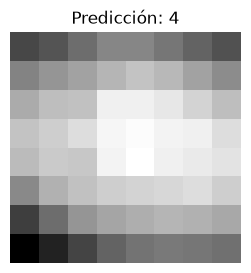

In [32]:
# Celda 8 - Predicciones del MLP en test
X_test_t = torch.tensor(X_test_esc, dtype=torch.float32)

modelo.eval()

with torch.no_grad():
    salida_test = modelo(X_test_t)
    pred_test_mlp = torch.argmax(salida_test, dim=1).numpy()

imagen_8x8 = Image.fromarray(imagen_array).resize((8, 8))
imagen_8x8_array = np.array(imagen_8x8)

X_imagen = imagen_8x8_array.flatten().reshape(1, -1)

X_imagen_esc = escalador.transform(X_imagen)

X_imagen_t = torch.tensor(X_imagen_esc, dtype=torch.float32)

with torch.no_grad():
    salida_imagen = modelo(X_imagen_t)
    prediccion_imagen = torch.argmax(salida_imagen, dim=1).item()

print(f"Predicción de la imagen: {prediccion_imagen}")

plt.figure(figsize=(3, 3))
plt.imshow(imagen_8x8_array, cmap="gray")
plt.title(f"Predicción: {prediccion_imagen}")
plt.axis("off")
plt.show()


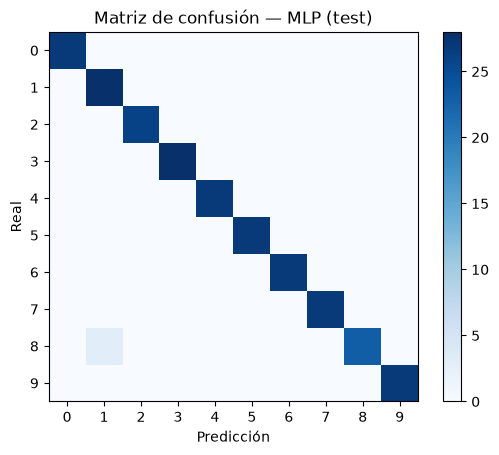

In [33]:
# Celda 9 — Matriz de confusión del MLP
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, pred_test_mlp)

plt.imshow(matriz, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP (test)")
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()


In [34]:
# BONO — ¿Cuánto ayuda realmente el dropout en este problema?
class MLPSinDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.red(x)
# Repetir el ciclo de entrenamiento de la Celda 6 con este modelo (sin dropout)
# y comparar la brecha final entre pérdida de train y de validation contra
# la del modelo original (con dropout).

In [18]:
# Preparar tensores
X_train_t = torch.tensor(X_train_esc, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_esc, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# Instanciar el modelo sin dropout
modelo_sin_dropout = MLPSinDropout()
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_sin_dropout.parameters(), lr=0.001)

mejor_val_loss = float("inf")
paciencia, epocas_sin_mejora = 15, 0
historial_sin_dropout = {"train_loss": [], "val_loss": []}

for epoch in range(200):
    modelo_sin_dropout.train()
    optimizador.zero_grad()
    salida = modelo_sin_dropout(X_train_t)
    perdida_train = criterio(salida, y_train_t)
    perdida_train.backward()
    optimizador.step()

    modelo_sin_dropout.eval()
    with torch.no_grad():
        salida_val = modelo_sin_dropout(X_val_t)
        perdida_val = criterio(salida_val, y_val_t)

    historial_sin_dropout["train_loss"].append(perdida_train.item())
    historial_sin_dropout["val_loss"].append(perdida_val.item())

    if perdida_val.item() < mejor_val_loss:
        mejor_val_loss = perdida_val.item()
        epocas_sin_mejora = 0
        mejores_pesos = {k: v.clone() for k, v in modelo_sin_dropout.state_dict().items()}
    else:
        epocas_sin_mejora += 1

    if epocas_sin_mejora >= paciencia:
        print(f"Early stopping en epoch {epoch} (sin mejora en {paciencia} epochs)")
        break

modelo_sin_dropout.load_state_dict(mejores_pesos)


<All keys matched successfully>

NameError: name 'historial_sin_dropout' is not defined

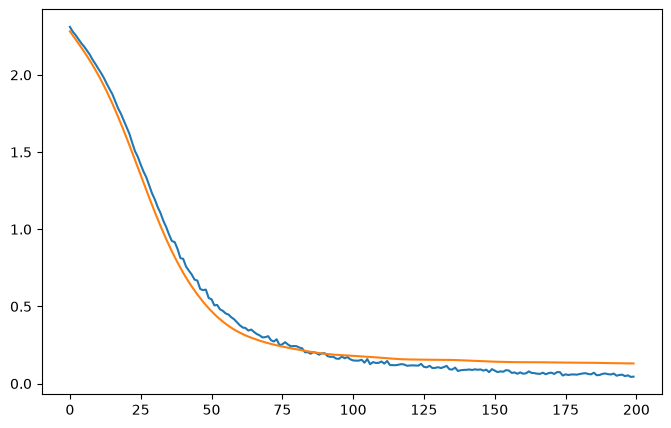

In [24]:
plt.figure(figsize=(8,5))
plt.plot(historial["train_loss"], label="Train (con dropout)")
plt.plot(historial["val_loss"], label="Val (con dropout)")
plt.plot(historial_sin_dropout["train_loss"], label="Train (sin dropout)", linestyle="--")
plt.plot(historial_sin_dropout["val_loss"], label="Val (sin dropout)", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparación de pérdidas — con vs sin dropout")
plt.legend()
plt.show()


Con dropout: la perdida de entrenamiento suele ser mas alta, pero la validacion se mantiene mas cercana = menor sobreajuste
Sin dropout: la perdida de entrenamiento baja mucho mas rápido, pero la validacion puede quedar mas separada = mayor brecha train/val